# Assignment - 1

### Dataset - Credit Risk Prediction

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

### Dataset Loading

In [14]:
df = pd.read_csv("german_credit_data.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


### Basic info for the dataset

In [15]:
print(df.shape)
print("\n\n\n")
df.info()
print("\n\n\n")
df.describe()

(1000, 11)




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB






,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


### Checking if there is any null column

In [16]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


### Data Cleaning

In [17]:
df["Saving accounts"] = df["Saving accounts"].fillna("Unknown")

df["Checking account"] = df["Checking account"].fillna("Unknown")

In [18]:
df = df.drop_duplicates()

In [19]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
Purpose,0


### Encoding

In [20]:
encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = encoder.fit_transform(df[column])

### EDA

#### Distribution of Risk

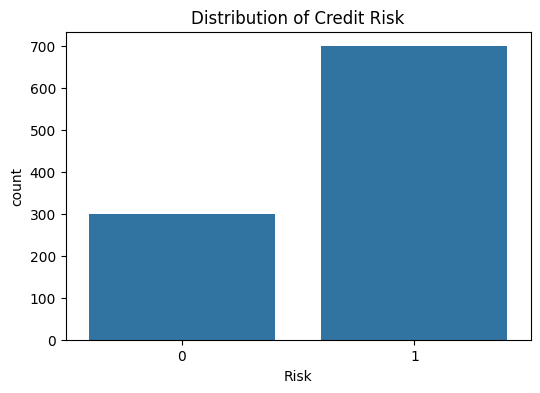

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x="Risk", data=df)
plt.title("Distribution of Credit Risk")
plt.show()

#### Age Distribution

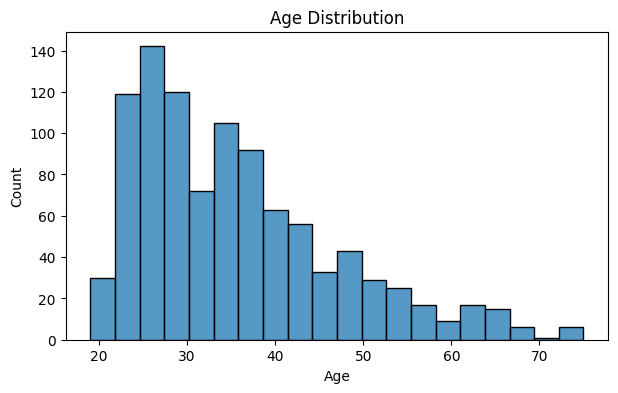

In [22]:
plt.figure(figsize=(7,4))
sns.histplot(df["Age"], bins=20)
plt.title("Age Distribution")
plt.show()

#### Credit amount distribution

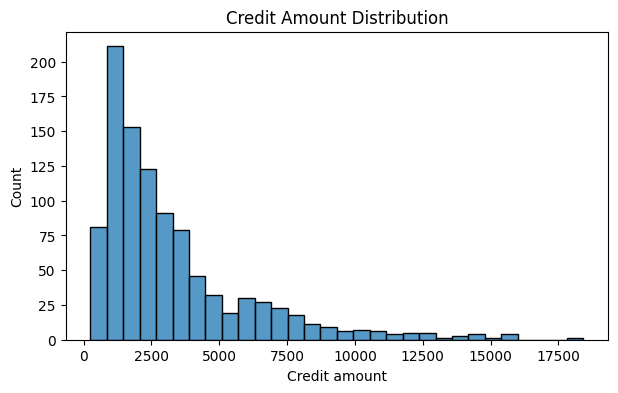

In [23]:
plt.figure(figsize=(7,4))
sns.histplot(df["Credit amount"], bins=30)
plt.title("Credit Amount Distribution")
plt.show()

#### Correlation Heatmap

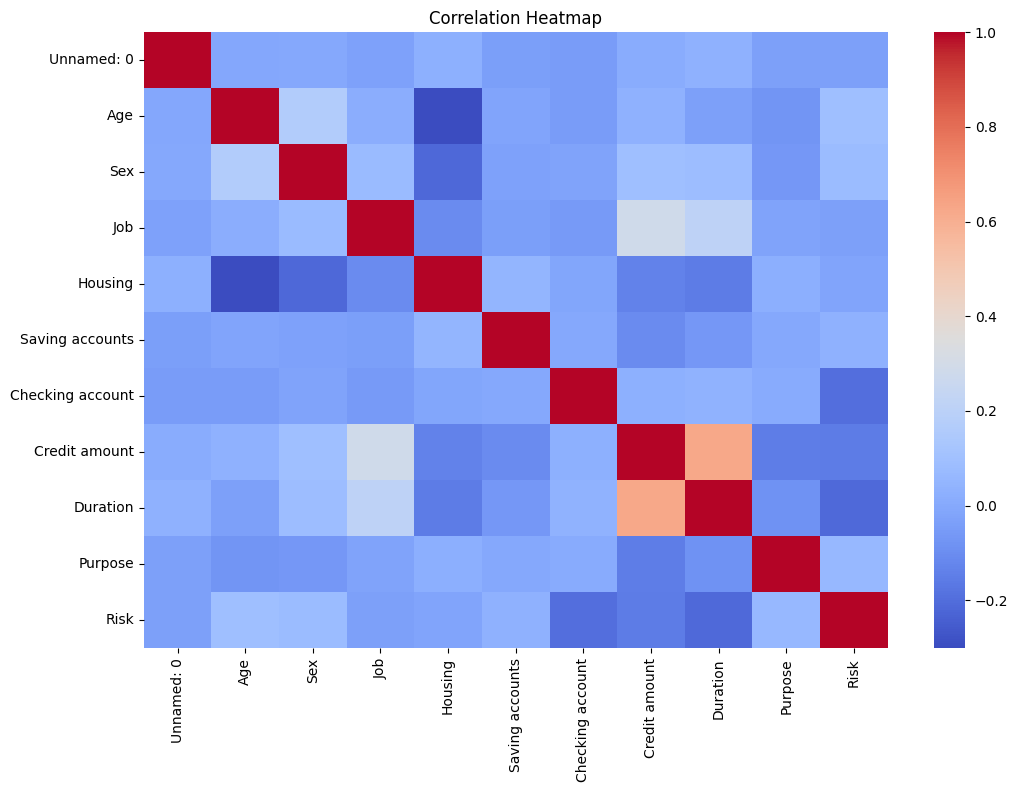

In [24]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#### Boxplot

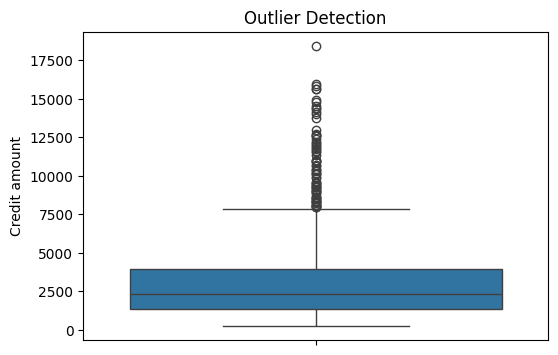

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Credit amount"])
plt.title("Outlier Detection")
plt.show()

## Observation
-----------------
• Observation 1

Applicants requesting higher credit amounts tend to show a higher proportion of bad credit risk.

• Observation 2

Most applicants belong to the good credit category, indicating the dataset is slightly imbalanced.



### Feature Selection

In [26]:
X = df.drop("Risk", axis=1)
y = df["Risk"]

### Train Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Training Model using Logistic Regression

In [29]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

### Prediction

In [30]:
predictions = model.predict(X_test)

### Evaluating the trained model

In [31]:
accuracy = accuracy_score(y_test, predictions)
print("Accuracy :", accuracy)

Accuracy : 0.705


In [32]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.50      0.14      0.21        59
           1       0.72      0.94      0.82       141

    accuracy                           0.70       200
   macro avg       0.61      0.54      0.52       200
weighted avg       0.66      0.70      0.64       200



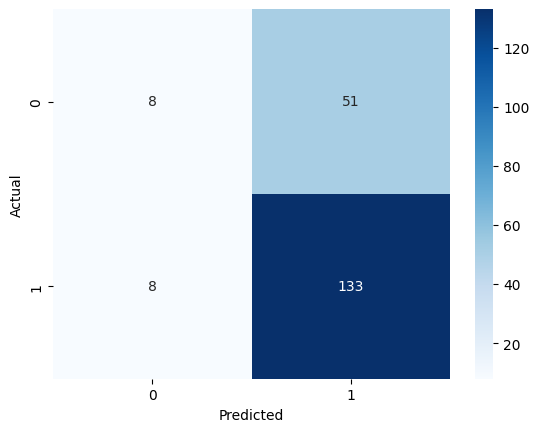

In [33]:
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Relation between Attributes

### Credit Amount Vs Risk

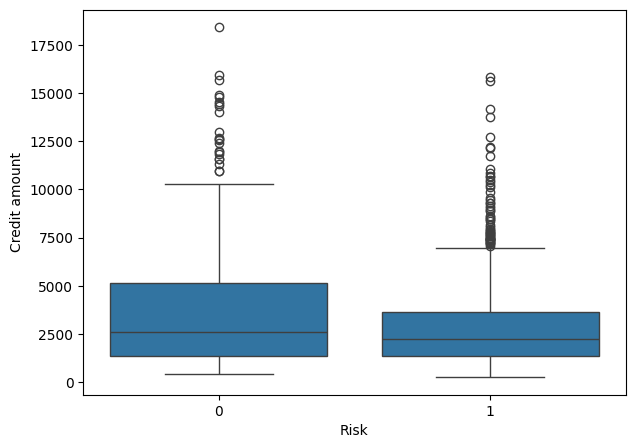

In [34]:
plt.figure(figsize=(7,5))
sns.boxplot(
    x="Risk",
    y="Credit amount",
    data=df
)
plt.show()

### Age vs Risk

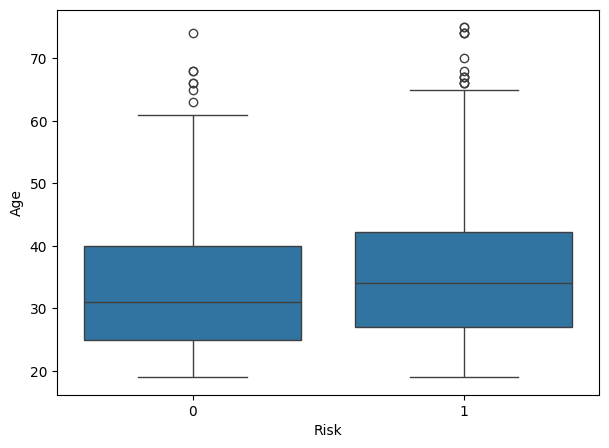

In [35]:
plt.figure(figsize=(7,5))
sns.boxplot(
    x="Risk",
    y="Age",
    data=df
)
plt.show()

Since we use Logistic Regression, the relationship is

P(Y=1)=
1/(1+e^
−(β
0
+β
1
x
1
+β
2
x
2
+⋯+β
n
x
n
))
	​


where:

• P(Y=1) is the probability of a customer being in one credit risk class

• β0 ​is the intercept

• βi are the learned coefficients

• xi are the applicant features.

### Abnormality Detection

In [36]:
Q1 = df["Credit amount"].quantile(0.25)
Q3 = df["Credit amount"].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Credit amount"] < lower) |
    (df["Credit amount"] > upper)
]
print(outliers)

     Unnamed: 0  Age  Sex  Job  Housing  Saving accounts  Checking account  \
5             5   35    1    1        0                0                 0   
17           17   25    1    2        1                0                 1   
18           18   44    0    3        0                1                 2   
57           57   31    0    2        1                1                 0   
63           63   25    1    2        1                1                 2   
..          ...  ...  ...  ...      ...              ...               ...   
927         927   39    1    2        0                1                 1   
945         945   30    0    2        1                3                 2   
953         953   26    0    3        1                1                 0   
980         980   49    1    2        1                1                 2   
983         983   26    1    2        1                1                 1   

     Credit amount  Duration  Purpose  Risk  
5             905

A small number of applicants requested unusually large loan amounts compared to the rest of the dataset. These observations are treated as outliers. Since they may represent genuine high-value loans, they were retained instead of removed.